In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_csv("project_data/FoodstuffsDemand2026.csv")  # read in data
data.head()

,Supermarket,4/05/2026,5/05/2026,6/05/2026,7/05/2026,8/05/2026,9/05/2026,10/05/2026,11/05/2026,12/05/2026,...,19/06/2026,20/06/2026,21/06/2026,22/06/2026,23/06/2026,24/06/2026,25/06/2026,26/06/2026,27/06/2026,28/06/2026
0,Four Square Botany Junction,4,1,3,1,4,0,0,2,4,...,2,0,0,1,4,1,2,3,1,0
1,Four Square Britomart,1,3,1,3,2,0,0,1,2,...,1,1,0,2,2,3,3,1,1,0
2,Four Square Cockle Bay,4,2,1,2,1,0,0,1,2,...,4,0,0,3,1,1,1,3,0,0
3,Four Square Eden Terrace,3,2,2,4,3,0,0,2,1,...,3,0,0,4,2,3,1,1,0,0
4,Four Square Ellerslie,2,4,3,4,2,0,0,1,1,...,4,0,0,1,4,4,1,2,1,0


In [36]:
data_melt = data.melt(id_vars="Supermarket", var_name="Date", value_name="Demand")

data_melt["Date"] = pd.to_datetime(data_melt["Date"], dayfirst=True)
data_melt["Day"] = data_melt["Date"].dt.day_name()

data_melt["Chain"] = ""
data_melt.loc[data_melt["Supermarket"].str.startswith("Four"), "Chain"] = "Four Square"
data_melt.loc[data_melt["Supermarket"].str.startswith("New"), "Chain"] = "New World"
data_melt.loc[data_melt["Supermarket"].str.startswith("Pak"), "Chain"] = "PAK'nSAVE"

data_melt

,Supermarket,Date,Demand,Day,Chain
0,Four Square Botany Junction,2026-05-04,4,Monday,Four Square
1,Four Square Britomart,2026-05-04,1,Monday,Four Square
2,Four Square Cockle Bay,2026-05-04,4,Monday,Four Square
3,Four Square Eden Terrace,2026-05-04,3,Monday,Four Square
4,Four Square Ellerslie,2026-05-04,2,Monday,Four Square
...,...,...,...,...,...
3075,Pak 'n Save Papakura,2026-06-28,0,Sunday,PAK'nSAVE
3076,Pak 'n Save Royal Oak,2026-06-28,0,Sunday,PAK'nSAVE
3077,Pak 'n Save Sylvia Park,2026-06-28,0,Sunday,PAK'nSAVE
3078,Pak 'n Save Wairau Road,2026-06-28,0,Sunday,PAK'nSAVE


In [37]:
data_melt = data_melt[data_melt["Day"] != "Sunday"] # exclude sundays, we already know this is 0
data_melt = data_melt[(data_melt["Date"] != "2026-06-01") & (data_melt["Demand"] < 20)]
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

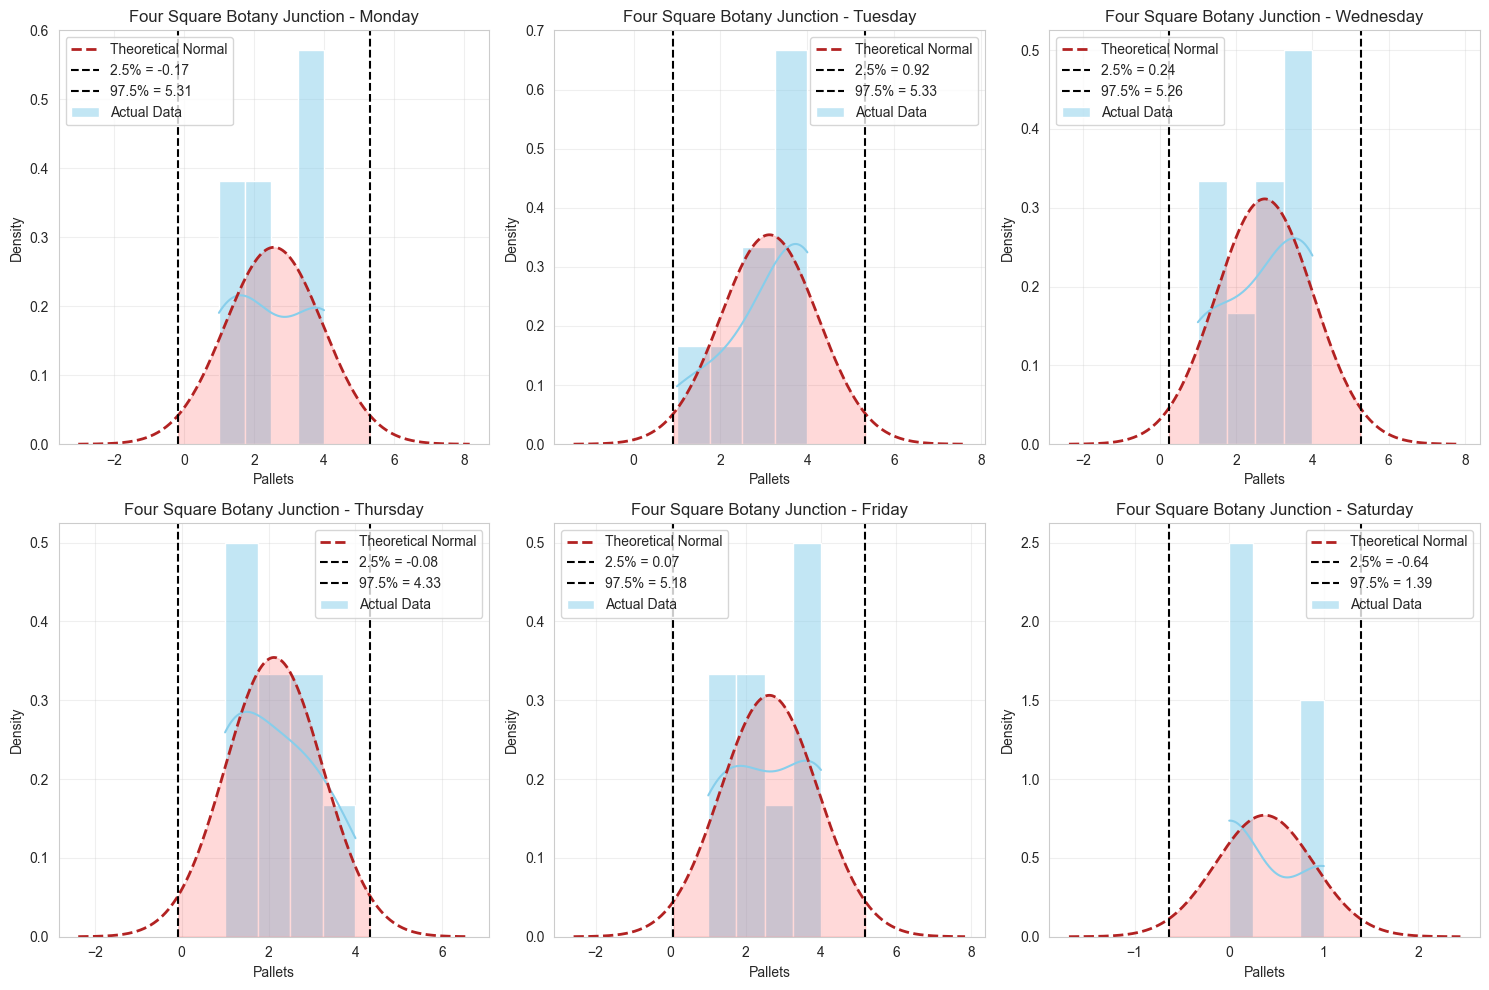

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, day in enumerate(days):
    # Filter store and day
    day_data = data_melt[
        (data_melt["Supermarket"] == "Four Square Botany Junction")
        & (data_melt["Day"] == day)
        ]["Demand"]

    # Skip plotting if there is no data for that day
    if day_data.empty:
        continue

    # Parameters
    mean = day_data.mean()
    std_dev = day_data.std()

    # Normal curve calculation
    x = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)
    y = norm.pdf(x, mean, std_dev)

    # 95th percentile bounds
    lower = mean - 1.96 * std_dev
    upper = mean + 1.96 * std_dev

    # UPDATED PLOTTING SECTION
    sns.set_style("whitegrid")

    # 1. Plot actual data distribution (histogram + empirical density)
    sns.histplot(
        day_data,
        stat="density",
        kde=True,
        ax=axes[i],
        color="skyblue",
        label="Actual Data",
    )

    # 2. Overlay theoretical normal curve
    axes[i].plot(
        x,
        y,
        color="firebrick",
        linewidth=2,
        linestyle="--",
        label="Theoretical Normal",
    )

    # 3. Shade middle 95% under theoretical curve
    shade = (x >= lower) & (x <= upper)
    axes[i].fill_between(x[shade], y[shade], color="red", alpha=0.15)

    # 4. Show bound lines
    axes[i].axvline(
        lower, color="black", linestyle="--", label=f"2.5% = {lower:.2f}"
    )
    axes[i].axvline(
        upper, color="black", linestyle="--", label=f"97.5% = {upper:.2f}"
    )

    # Formatting
    axes[i].set_title(f"Four Square Botany Junction - {day}")
    axes[i].set_xlabel("Pallets")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# Calculate mean and standard deviation for each store and day
mean = data_melt.groupby(["Supermarket", "Day"])["Demand"].mean()
std_dev = data_melt.groupby(["Supermarket", "Day"])["Demand"].std()

# Calculate upper 95% bound
upper = mean + 1.96 * std_dev

# Round up to whole pallets
estimate = np.ceil(upper).astype(int)

# Add warehouse rows with zero demand
warehouse_rows = pd.Series(
    0,
    index=pd.MultiIndex.from_product(
        [["Warehouse"], estimate.index.get_level_values("Day").unique()],
        names=["Supermarket", "Day"]
    )
)

# Combine with estimates
estimate = pd.concat(
    [estimate, warehouse_rows]
)

estimate = estimate.rename("Demand").reset_index()

estimate

,Supermarket,Day,Demand
0,Four Square Botany Junction,Friday,6
1,Four Square Botany Junction,Monday,6
2,Four Square Botany Junction,Saturday,2
3,Four Square Botany Junction,Thursday,5
4,Four Square Botany Junction,Tuesday,6
...,...,...,...
331,Warehouse,Monday,0
332,Warehouse,Saturday,0
333,Warehouse,Thursday,0
334,Warehouse,Tuesday,0


In [40]:
# Create weekday category
data_melt["Period"] = ""

data_melt.loc[data_melt["Day"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]), "Period"] = "Weekdays"

data_melt.loc[data_melt["Day"] == "Saturday", "Period"] = "Saturday"



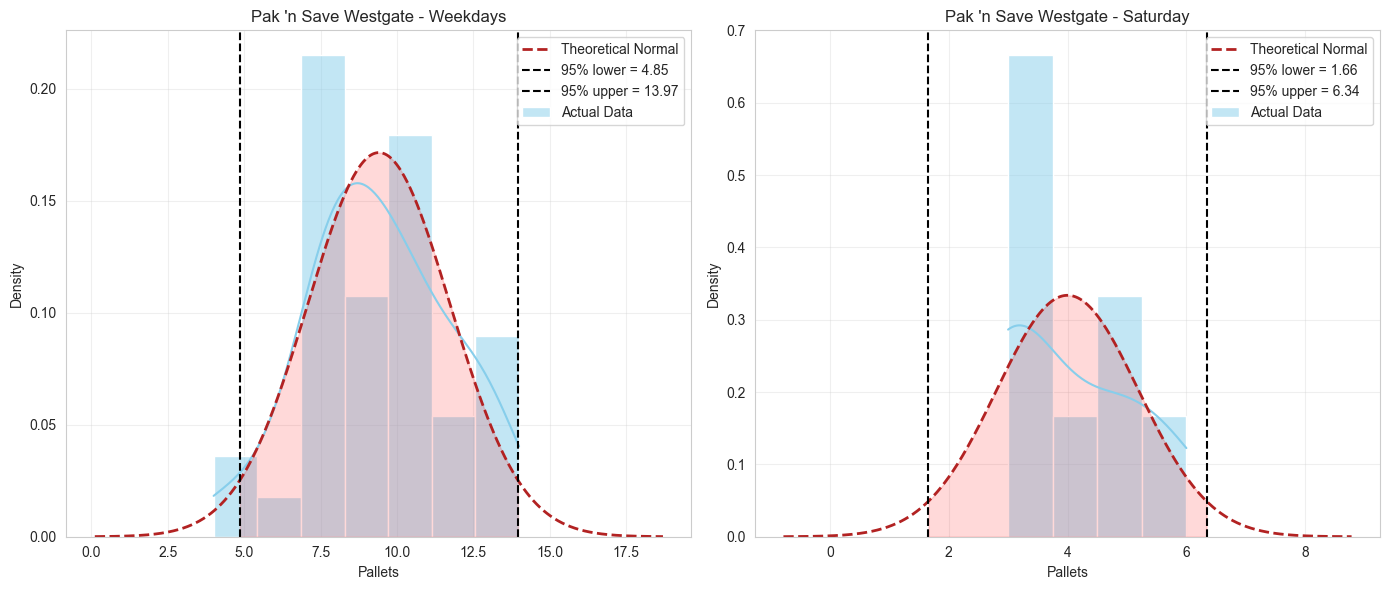

In [41]:
store = "Pak 'n Save Westgate"
periods = ["Weekdays", "Saturday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, period in enumerate(periods):
    # Filter store and period
    demand = data_melt[
        (data_melt["Supermarket"] == store) & (data_melt["Period"] == period)
        ]["Demand"]

    # Skip plotting if there is no data for that period
    if demand.empty:
        continue

    # Parameters
    mean = demand.mean()
    std_dev = demand.std()

    # Normal curve calculation
    x = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)
    y = norm.pdf(x, mean, std_dev)

    # 95% bounds
    lower = mean - 1.96 * std_dev
    upper = mean + 1.96 * std_dev

    # ----------------------------------------------------
    # UPDATED PLOTTING SECTION
    # ----------------------------------------------------
    sns.set_style("whitegrid")

    # 1. Plot actual data distribution (histogram + empirical density)
    sns.histplot(
        demand,
        stat="density",
        kde=True,
        ax=axes[i],
        color="skyblue",
        label="Actual Data",
    )

    # 2. Overlay theoretical normal curve
    axes[i].plot(
        x,
        y,
        color="firebrick",
        linewidth=2,
        linestyle="--",
        label="Theoretical Normal",
    )

    # 3. Shade 95% range under theoretical curve
    shade = (x >= lower) & (x <= upper)
    axes[i].fill_between(x[shade], y[shade], color="red", alpha=0.15)

    # 4. Upper & lower bound lines
    axes[i].axvline(
        lower, color="black", linestyle="--", label=f"95% lower = {lower:.2f}"
    )
    axes[i].axvline(
        upper, color="black", linestyle="--", label=f"95% upper = {upper:.2f}"
    )

    # Formatting
    axes[i].set_title(f"{store} - {period}")
    axes[i].set_xlabel("Pallets")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
mean = data_melt.groupby(["Supermarket", "Period"])["Demand"].mean()

std_dev = data_melt.groupby(["Supermarket", "Period"])["Demand"].std()

# Upper 95% bound
upper = mean + 1.96 * std_dev

# Round up to whole pallets
new_estimate = np.ceil(upper).astype(int)

# Add warehouse rows
warehouse_rows = pd.Series(
    0,
    index=pd.MultiIndex.from_product(
        [["Warehouse"], new_estimate.index.get_level_values("Period").unique()],
        names=["Supermarket", "Period"]
    )
)

# Combine with demand estimates
new_estimate = pd.concat(
    [new_estimate, warehouse_rows]
)
new_estimate = new_estimate.rename("Demand").reset_index()

new_estimate

,Supermarket,Period,Demand
0,Four Square Botany Junction,Saturday,2
1,Four Square Botany Junction,Weekdays,6
2,Four Square Britomart,Saturday,2
3,Four Square Britomart,Weekdays,5
4,Four Square Cockle Bay,Saturday,0
...,...,...,...
107,Pak 'n Save Wairau Road,Weekdays,14
108,Pak 'n Save Westgate,Saturday,7
109,Pak 'n Save Westgate,Weekdays,14
110,Warehouse,Saturday,0


In [43]:
import os

# Make sure project_data exists
os.makedirs("project_data", exist_ok=True)

# Save demand_estimate.csv to project_data
new_estimate.to_csv(
    "project_data/demand_estimate.csv",
    index=False
)

print(
    "Saved: project_data/demand_estimate.csv"
)

Saved: project_data/demand_estimate.csv


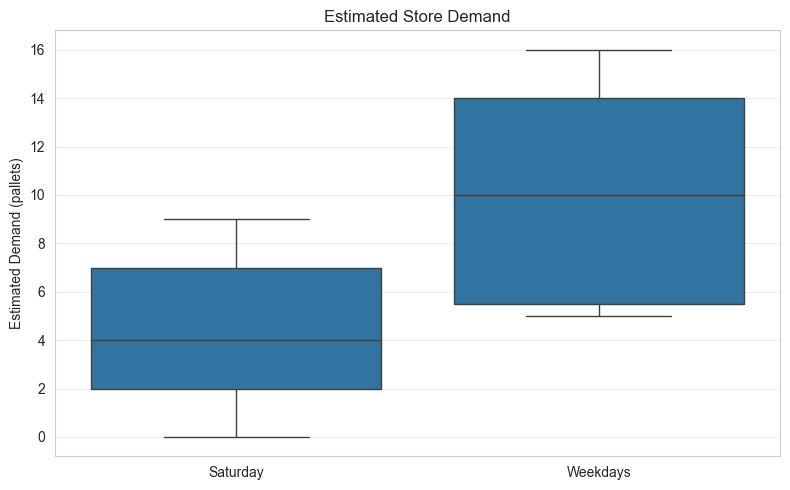

In [44]:
# Boxplots of estimated demand across stores

plot_data = new_estimate[new_estimate["Supermarket"] != "Warehouse"]

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=plot_data,
    x="Period",
    y="Demand"
)

ax.set_title("Estimated Store Demand")
ax.set_xlabel("")
ax.set_ylabel("Estimated Demand (pallets)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

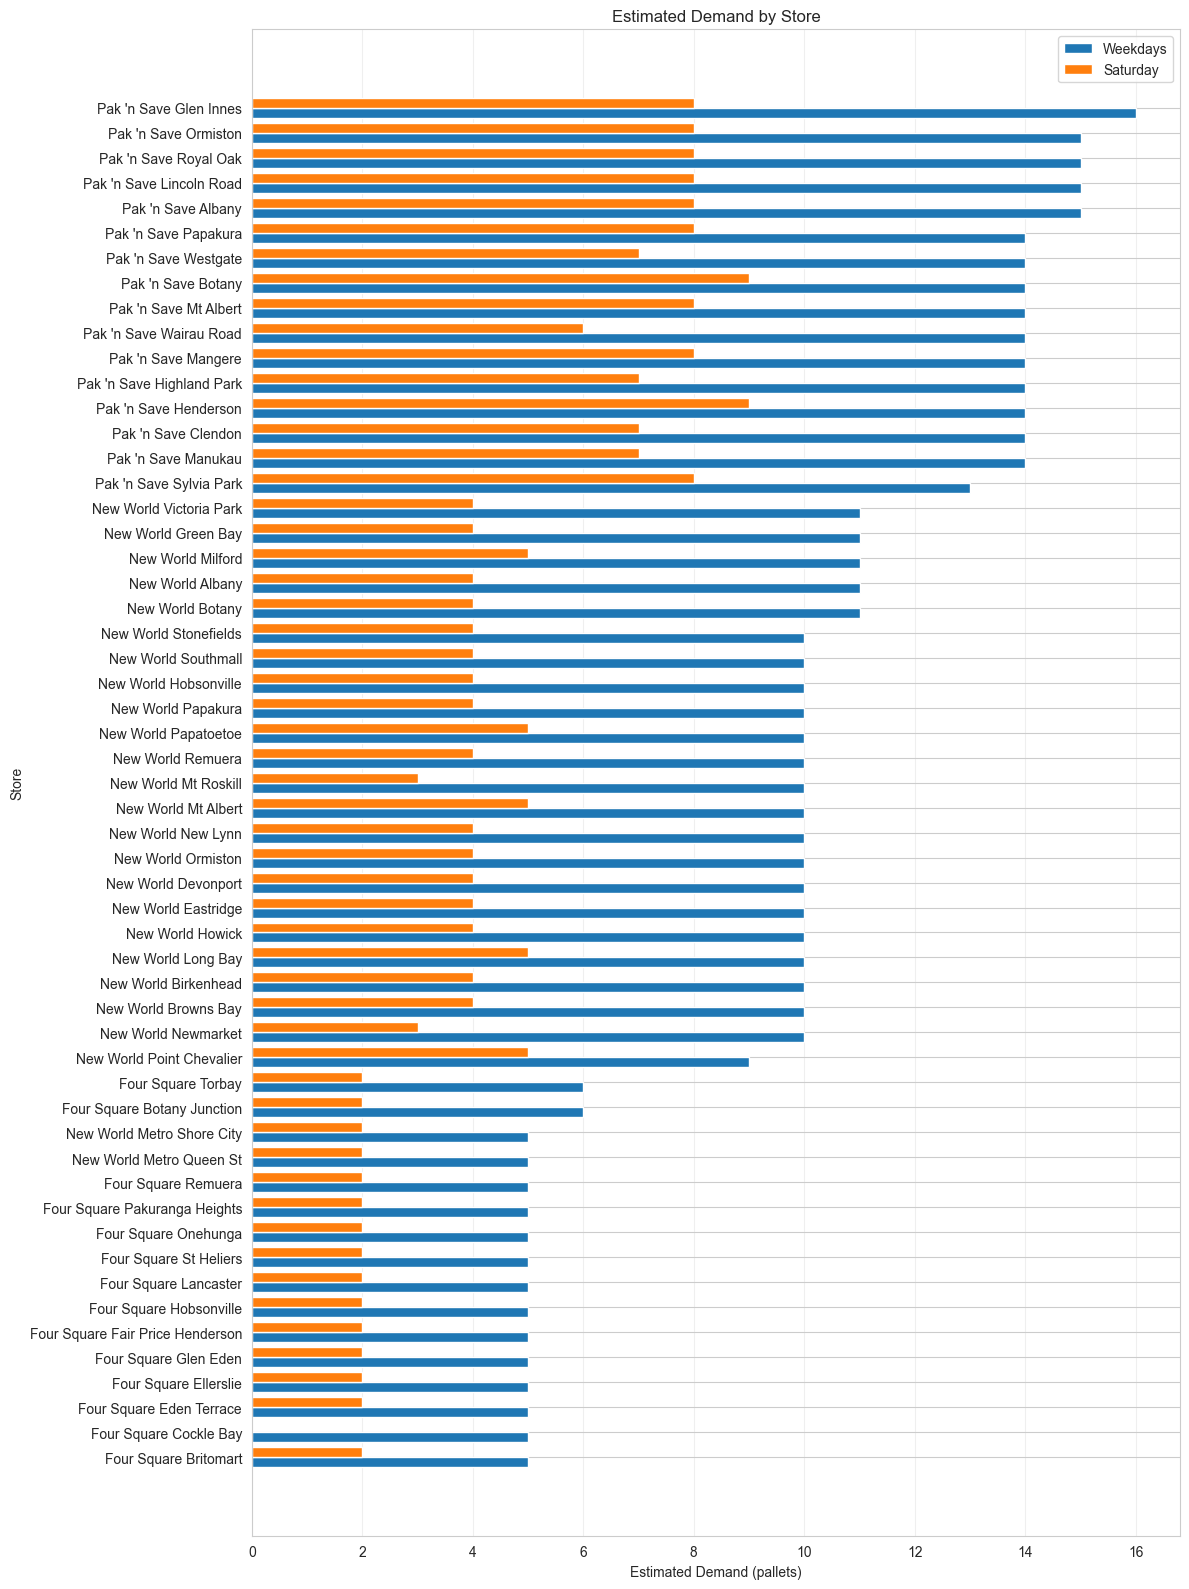

In [45]:
# Horizontal bar chart of estimated demand

plot_data = new_estimate[new_estimate["Supermarket"] != "Warehouse"].copy()

plot_data = plot_data.pivot(
    index="Supermarket",
    columns="Period",
    values="Demand"
).reset_index()

plot_data = plot_data.sort_values("Weekdays")

fig, ax = plt.subplots(figsize=(12, 16))

y = np.arange(len(plot_data))
height = 0.4

ax.barh(
    y - height / 2,
    plot_data["Weekdays"],
    height,
    label="Weekdays"
)

ax.barh(
    y + height / 2,
    plot_data["Saturday"],
    height,
    label="Saturday"
)

ax.set_xlabel("Estimated Demand (pallets)")
ax.set_ylabel("Store")
ax.set_title("Estimated Demand by Store")
ax.set_yticks(y)
ax.set_yticklabels(plot_data["Supermarket"])
ax.legend()

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()